In [80]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import tqdm
import pandas as pd

In [81]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


In [82]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=4.51e6):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

        raise KeyError(
            f"Neither state/S nor state/mixed_state found. Available state vars: {sorted(state_hist.keys())}"
        )

In [83]:
nmodel = neml2.load_model("new_model_test.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["Bk_X", "C_X", "E_X", "E_Y", "G_X", "G_Y", "H_0_X",
                                                                            "T_0_X", "T_ref_X", "T_ref_Y", "athermal_alpha", "athermal_b",
                                                                            "elasticity_nu", "flow_rate_b", "g_X", "k1_X", "k2_X",
                                                                            "shear_athermal_m", "shear_eff_m", "sy_X", "sy_Y", "tau_p_X",
                                                                            "tau_p_Y", "v_disl_a", "v_disl_b", "v_disl_h", "v_disl_p", "v_disl_q"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: Bk_X [Scalar][Double][cuda:0]
            Bk_Y [Scalar][Double][cuda:0]
            C_X [Scalar][Double][cuda:0]
            C_Y [Scalar][Double][cuda:0]
            E_X [Scalar][Double][cuda:0]
            E_Y [Scalar][Double][cuda:0]
       

C116: 250C, 6.40e-03 1/s: strain range [0.0620, 4.9760]
C120: 550C, 6.40e-03 1/s: strain range [0.0020, 4.9820]
C103: 550C, 6.40e-04 1/s: strain range [0.0006, 4.9643]
C117: 400C, 6.40e-03 1/s: strain range [0.0540, 4.9690]
C119: 550C, 6.40e-03 1/s: strain range [0.0050, 4.8470]
C107: 250C, 6.40e-04 1/s: strain range [0.0170, 4.9870]
C115: 250C, 6.40e-03 1/s: strain range [0.1240, 4.9720]
C114: 400C, 6.40e-03 1/s: strain range [0.0121, 4.9039]
C113: 400C, 6.40e-02 1/s: strain range [0.0007, 4.6631]
480C, 6.00e-04 1/s: strain range [0.0215, 1.1943]
C106: 550C, 6.40e-04 1/s: strain range [0.0003, 4.9927]
C108: 400C, 6.40e-04 1/s: strain range [0.0100, 4.9930]
C102: 400C, 6.40e-04 1/s: strain range [0.0530, 5.0000]
C105: 400C, 6.40e-04 1/s: strain range [0.0040, 4.9960]
C123: 400C, 6.40e-03 1/s: strain range [0.0140, 4.8330]
C122: 550C, 6.40e-02 1/s: strain range [0.0013, 4.8306]
C109: 550C, 6.40e-04 1/s: strain range [0.0040, 4.9530]
C104: 250C, 6.40e-04 1/s: strain range [0.0012, 4.9907

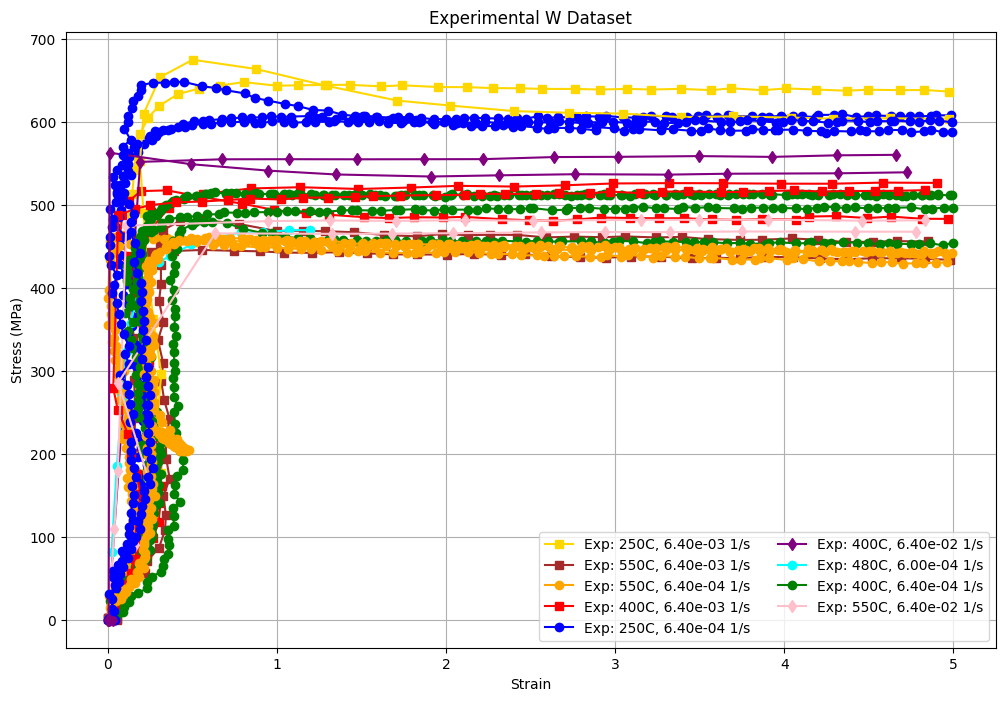

In [84]:
# Load experimental data
path = '/home/colinmg/neml2/cmg_projects/stress-strain/advanced_model/tests/W_test_data'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        sample_name = filename.split('_')[1]
        if '250C' in filename:
            temp_str = 250
            if sample_name in ['C101', 'C104', 'C107']:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C115', 'C116']:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif '400C' in filename:
            temp_str = 400
            if sample_name in ['C102', 'C105', 'C108']:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C114', 'C117', 'C123']:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C113', 'C118']:
                strain_rate_str = 6.4e-2
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif '550C' in filename:
            temp_str = 550
            if sample_name in ['C103', 'C106', 'C109']:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C119', 'C120']:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C121', 'C122']:
                strain_rate_str = 6.4e-2
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif '480C' in filename:
            temp_str = 480
            strain_rate_str = 6.0e-4
            label = f"{temp_str}C, {strain_rate_str:.2e} 1/s"
        else:
            # Skip CSV files that are not part of the deterministic calibration set. This excludes 300C dataset
            continue
        
        new_df = df.rename(columns={'x':f'{label}_strain', 'y':f'{label}_stress'})
        data_frames[label] = new_df

strain_data = {}
stress_data = {}

for label, df in data_frames.items():
    strain_col = f'{label}_strain'
    stress_col = f'{label}_stress'
    if ": " in label:
        strain = torch.tensor(df[strain_col].values * 100, device=device)
    else:
        strain = torch.tensor(df[strain_col].values, device=device)
        
    stress = torch.tensor(df[stress_col].values, device=device)

    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]

    mask = (stress > 0) & (strain <= 5) & (strain > 0)
    strain = strain[mask]
    stress = stress[mask]

    strain_data[label] = strain
    stress_data[label] = stress

exp_conditions = []
for label, df in data_frames.items():
    if ':' in label:
        temp_str = re.split(r'[:,]', label)[1]
        strain_rate_str = re.split(r'[:,]', label)[2]
    else:
        temp_str = label.split(',')[0]
        strain_rate_str = label.split(',')[1]

    temp = float(temp_str.replace('C', '').strip()) + 273.15 # convert to Kelvin
    strain_rate = float(strain_rate_str.replace('1/s', '').strip())
    exp_conditions.append((temp, strain_rate, label))

for i, (temp, rate, label) in enumerate(exp_conditions):
    min_strain = strain_data[label].min().item()
    max_strain = strain_data[label].max().item()
    
    # Experimental strain ranges
    print(f"{label}: strain range [{min_strain:.4f}, {max_strain:.4f}]")

style_map = {
    (250, 6.4e-4): ('blue',   'o'),
    (250, 6.4e-3): ('gold',   's'),
    (400, 6.4e-4): ('green',  'o'),
    (400, 6.4e-3): ('red',    's'),
    (400, 6.4e-2): ('purple', 'd'),
    (480, 6.0e-4): ('cyan',   'o'),
    (550, 6.4e-4): ('orange', 'o'),
    (550, 6.4e-3): ('brown',  's'),
    (550, 6.4e-2): ('pink',   'd'),
}

# Plot initial dataset
plt.figure(figsize=(12,8))
plotted_conditions = set()
for label in strain_data:
    T_exp = next(T for T, r, l in exp_conditions if l == label)
    rate_exp = next(r for T, r, l in exp_conditions if l == label)
    temp_C = round(T_exp - 273.15)
    color, marker = style_map.get((temp_C, rate_exp), ('k', 'o'))

    # Only add one legend entry per condition (not one per replicate)
    cond_key = (temp_C, rate_exp)
    legend_label = f"Exp: {temp_C}C, {rate_exp:.2e} 1/s" if cond_key not in plotted_conditions else "_nolegend_"
    plotted_conditions.add(cond_key)
    plt.plot(strain_data[label].cpu().numpy(), stress_data[label].cpu().numpy(),color=color, marker=marker, label=legend_label)
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Experimental W Dataset')
plt.grid()
plt.legend(loc='lower right', ncol=2)
plt.show()

In [85]:
batch_conditions = [
    (523.15, 6.4e-4),
    (523.15, 6.4e-3),
    (673.15, 6.4e-4),
    (673.15, 6.4e-3),
    (673.15, 6.4e-2),
    (753.15, 6.0e-4),
    (823.15, 6.4e-4),
    (823.15, 6.4e-3),
    (823.15, 6.4e-2)
]

temperatures = torch.tensor([c[0] for c in batch_conditions], device=device)
rates = torch.tensor([c[1] for c in batch_conditions], device=device)

nbatch = len(batch_conditions)
ntime = 100

time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(batch_conditions):
    max_strain = 5.0
    strain_values = torch.linspace(0.0, max_strain, ntime, device=device)
    time_values = torch.linspace(0.0, max_strain/rate, ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature (in Kelvin)
    temperature[:, i, 0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")



--- Full Input Tensors ---
time: torch.Size([100, 9, 1])
temperature: torch.Size([100, 9, 1])
loading: torch.Size([100, 9, 6])


    Batch 0 250C 6.40e-04 1/s -> 3 curves: ['C107: 250C, 6.40e-04 1/s', 'C104: 250C, 6.40e-04 1/s', 'C101: 250C, 6.40e-04 1/s']
    Batch 1 250C 6.40e-03 1/s -> 2 curves: ['C116: 250C, 6.40e-03 1/s', 'C115: 250C, 6.40e-03 1/s']
    Batch 2 400C 6.40e-04 1/s -> 3 curves: ['C108: 400C, 6.40e-04 1/s', 'C102: 400C, 6.40e-04 1/s', 'C105: 400C, 6.40e-04 1/s']
    Batch 3 400C 6.40e-03 1/s -> 3 curves: ['C117: 400C, 6.40e-03 1/s', 'C114: 400C, 6.40e-03 1/s', 'C123: 400C, 6.40e-03 1/s']
    Batch 4 400C 6.40e-02 1/s -> 2 curves: ['C113: 400C, 6.40e-02 1/s', 'C118: 400C, 6.40e-02 1/s']
    Batch 5 480C 6.00e-04 1/s -> 1 curves: ['480C, 6.00e-04 1/s']
    Batch 6 550C 6.40e-04 1/s -> 3 curves: ['C103: 550C, 6.40e-04 1/s', 'C106: 550C, 6.40e-04 1/s', 'C109: 550C, 6.40e-04 1/s']
    Batch 7 550C 6.40e-03 1/s -> 2 curves: ['C120: 550C, 6.40e-03 1/s', 'C119: 550C, 6.40e-03 1/s']
    Batch 8 550C 6.40e-02 1/s -> 2 curves: ['C122: 550C, 6.40e-02 1/s', 'C121: 550C, 6.40e-02 1/s']
Interpolated data shap

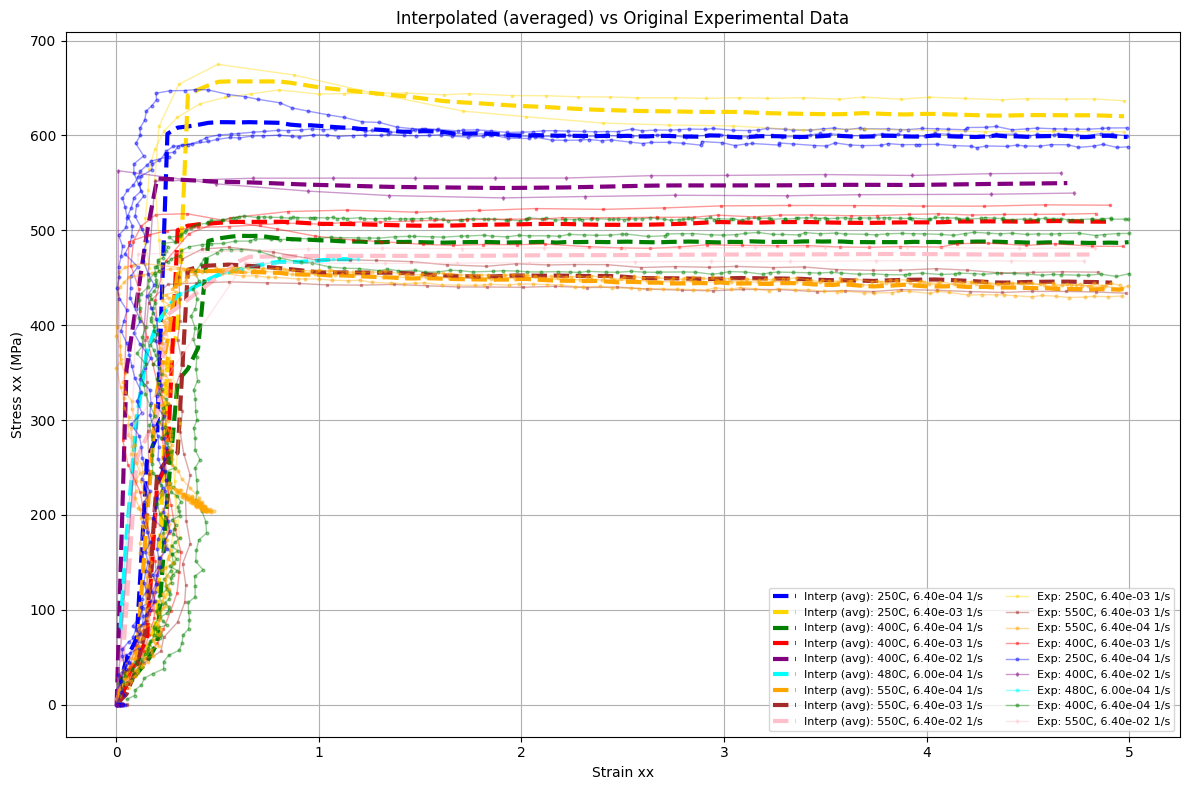

In [86]:
from collections import defaultdict

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

batch_to_labels = defaultdict(list)
for i, (bT, b_rate) in enumerate(batch_conditions):
    for j, (T, rate, label) in enumerate(exp_conditions):
        if abs(T - bT) == 0.0 and abs(rate - b_rate) == 0.0:
            batch_to_labels[i].append(label)

for i, (T, rate) in enumerate(batch_conditions):
    labels = batch_to_labels.get(i, [])
    print(f'    Batch {i:d} {T-273.15:.0f}C {rate:.2e} 1/s -> {len(labels)} curves: {labels}')

    target_strain = loading[:, i, 0].cpu().numpy()
    
    replicate_strains = []
    replicate_stresses = []

    for label in labels:
        src_strain = strain_data[label].cpu().numpy()
        src_stress = stress_data[label].cpu().numpy()

        tgt_clipped = np.clip(target_strain, src_strain.min(), src_strain.max())
        interp_stress = np.interp(tgt_clipped, src_strain, src_stress)

        replicate_strains.append(tgt_clipped)
        replicate_stresses.append(interp_stress)

    mean_strain = np.mean(replicate_strains, axis=0)
    mean_stress = np.mean(replicate_stresses, axis=0)

    exp_strain_data[:, i, 0] = torch.tensor(mean_strain, device=device)
    exp_stress_data[:, i, 0] = torch.tensor(mean_stress, device=device)
 
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

print("Saturated Stress values")
for i, (T, rate) in enumerate(batch_conditions):
    print(f'  Batch {i} {T-273.15}C {rate:.2e} 1/s -> {exp_stress_data[-1, i, 0].item():.2f} MPa')

# Color/marker scheme keyed by (temp_C, rate)
style_map = {
    (250, 6.4e-4): ('blue',   'o'),
    (250, 6.4e-3): ('gold',   's'),
    (400, 6.4e-4): ('green',  'o'),
    (400, 6.4e-3): ('red',    's'),
    (400, 6.4e-2): ('purple', 'd'),
    (480, 6.0e-4): ('cyan',   'o'),
    (550, 6.4e-4): ('orange', 'o'),
    (550, 6.4e-3): ('brown',  's'),
    (550, 6.4e-2): ('pink',   'd'),
}

fig, ax = plt.subplots(figsize=(12, 8))

# ── Interpolated (averaged) curves ──────────────────────────────────────────
for i, (T, rate) in enumerate(batch_conditions):
    temp_C = round(T - 273.15)
    color, _ = style_map.get((temp_C, rate), (f'C{i}', 'o'))
    batch_label = f"{temp_C}C, {rate:.2e} 1/s"
    ax.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        '--', color=color, lw=3,
        label=f"Interp (avg): {batch_label}",
    )

# ── Original replicate curves ────────────────────────────────────────────────
plotted_conditions = set()
for label in strain_data:
    T_exp = next(T for T, r, l in exp_conditions if l == label)
    rate_exp = next(r for T, r, l in exp_conditions if l == label)
    temp_C = round(T_exp - 273.15)
    color, marker = style_map.get((temp_C, rate_exp), ('k', 'o'))

    # Only add one legend entry per condition (not one per replicate)
    cond_key = (temp_C, rate_exp)
    legend_label = f"Exp: {temp_C}C, {rate_exp:.2e} 1/s" if cond_key not in plotted_conditions else "_nolegend_"
    plotted_conditions.add(cond_key)

    ax.plot(
        strain_data[label].cpu().numpy(),
        stress_data[label].cpu().numpy(),
        color=color, alpha=0.4, lw=1, marker=marker, markersize=2,
        label=legend_label,
    )

ax.set_xlabel("Strain xx")
ax.set_ylabel("Stress xx (MPa)")
ax.set_title("Interpolated (averaged) vs Original Experimental Data")
ax.grid(True)
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [87]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[   0.0000],
         [   0.0000],
         [   0.0000],
         [   0.0000],
         [   0.0000],
         [   0.0000],
         [   0.0000],
         [   0.0000],
         [   0.0000]],

        [[ 202.0177],
         [ 202.0200],
         [ 100.7224],
         [ 100.9784],
         [ 101.0069],
         [  84.0429],
         [  78.3247],
         [  81.9502],
         [  83.1166]],

        [[ 403.9763],
         [ 404.0339],
         [ 200.3441],
         [ 201.8048],
         [ 201.9977],
         [ 163.4552],
         [ 140.2304],
         [ 160.7110],
         [ 165.6451]],

        [[ 605.1693],
         [ 605.9650],
         [ 296.8813],
         [ 302.1337],
         [ 302.9295],
         [ 228.7866],
         [ 172.7574],
         [ 230.2621],
         [ 246.9134]],

        [[ 800.4758],
         [ 807.0864],
         [ 383.9634],
         [ 401.1622],
         [ 403.6808],
         [ 270.7678],
         [ 186.0595],
         [ 281.2309],
         [ 325.3018]],



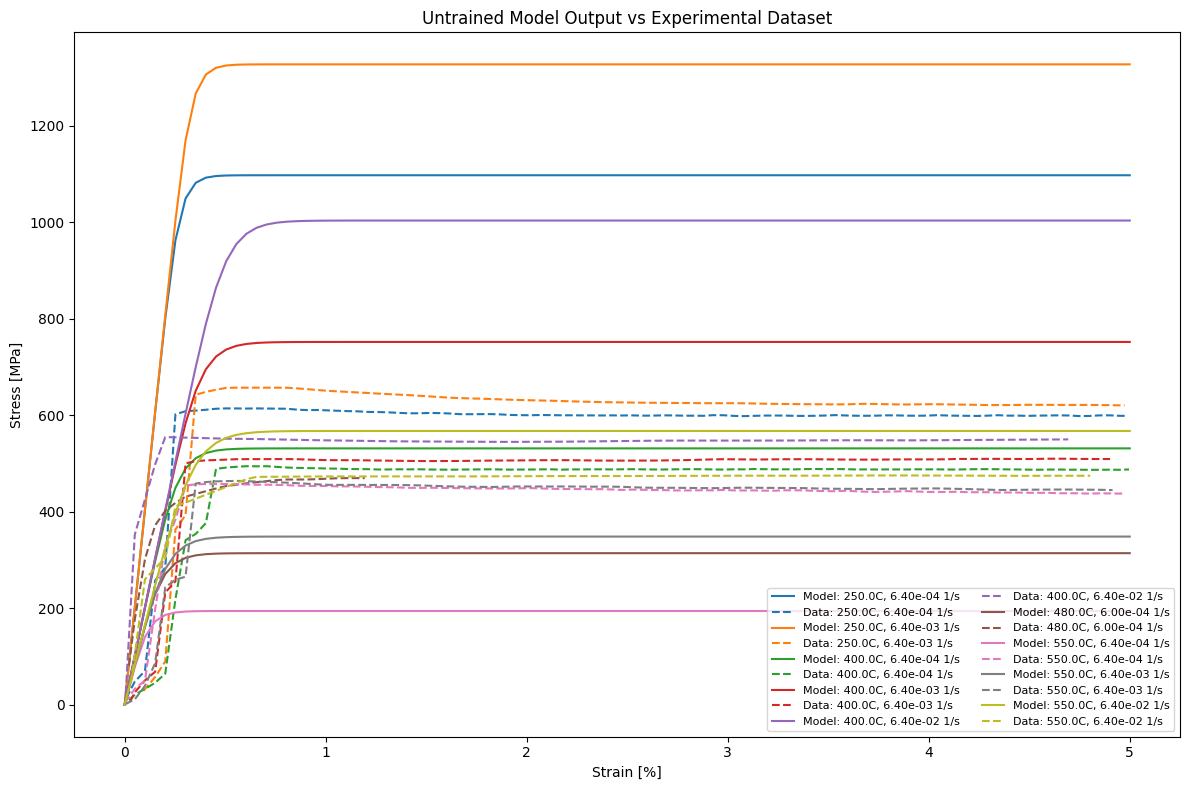

In [88]:
plt.figure(figsize=(12,8))
for i, (T, rate) in enumerate(batch_conditions):
    batch_label = f'{T - 273.15}C, {rate:.2e} 1/s'
    plt.plot(loading[:, i, 0].cpu().numpy(), stress[:, i, 0].cpu().numpy(), color=f'C{i}', label=f'Model: {batch_label}')
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--',color=f'C{i}', label=f'Data: {batch_label}')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.xlabel('Strain [%]')
plt.ylabel('Stress [MPa]')
plt.title('Untrained Model Output vs Experimental Dataset')
plt.tight_layout()
plt.show()

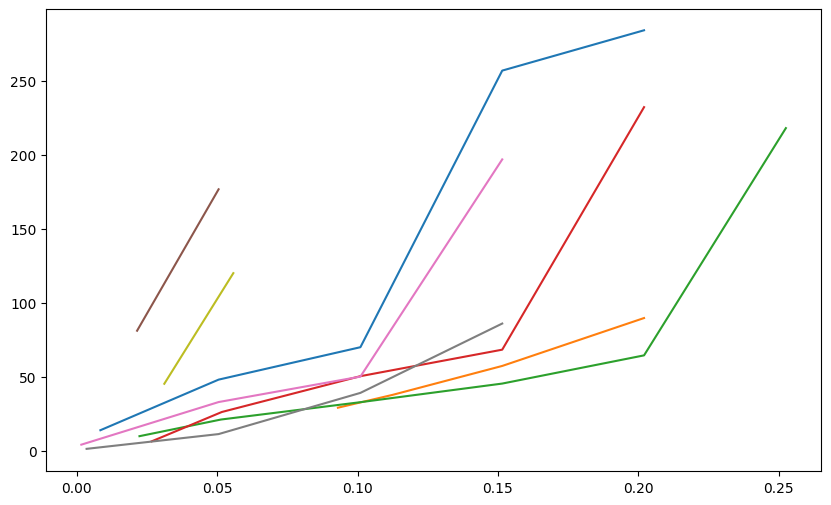

In [79]:
# Find the yield stress for each temperature
E = nmodel.E_Y.tensor().clone().torch()  # interpolation ordinate for E
sy = nmodel.sy_Y.tensor().clone().torch()  # interpolation ordinate for sy
nu = nmodel.elasticity_nu.tensor().clone().torch()
offset = 0.002

sy_exps = []
E_exps = []

plt.figure(figsize=(10, 6))

for i, (T, rate) in enumerate(batch_conditions):

    # Calculate actual experimental Young's Modulus
    # Grab experimental data (keep on GPU)
    stress_exp = exp_stress_data[:, i, 0]
    strain_range = exp_strain_data[:, i, 0]

    peak_stress = stress_exp.max()
    elastic_stress_fraction = 0.5
    elastic_mask = stress_exp < peak_stress * elastic_stress_fraction

    strain_el = strain_range[elastic_mask]
    stress_el = stress_exp[elastic_mask]
    plt.plot(strain_el.cpu().numpy(), stress_el.cpu().numpy())

#     # Build 0.2% offset line: E * (strain - 0.002), zero below offset
#     valid_idx = strain_range >= offset
#     stress_offset = torch.zeros_like(strain_range)
#     stress_offset[valid_idx] = E_exp * (strain_range[valid_idx] - offset)

#     # Find yield point: first sign change of (stress_exp - stress_offset) in valid region
#     diff = stress_exp - stress_offset
#     diff_valid = diff[valid_idx]
#     strain_valid = strain_range[valid_idx]
#     stress_valid = stress_exp[valid_idx]

#     sign_changes = torch.where(torch.diff(torch.sign(diff_valid)) != 0)[0]

#     if len(sign_changes) > 0:
#         idx = sign_changes[0].item()
#         # Linear interpolation between the two bracketing points
#         d0, d1 = diff_valid[idx].item(), diff_valid[idx + 1].item()
#         s0, s1 = strain_valid[idx].item(), strain_valid[idx + 1].item()
#         se0, se1 = stress_valid[idx].item(), stress_valid[idx + 1].item()

#         t = d0 / (d0 - d1)  # interpolation parameter in [0, 1]
#         yield_strain = s0 + t * (s1 - s0)
#         yield_stress = se0 + t * (se1 - se0)

#         sy_exps.append(yield_stress)
#         print(f"  Yield stress: {yield_stress:.2f} MPa at strain: {yield_strain:.4f}")
#         plt.plot(yield_strain, yield_stress, "ko", markersize=7, zorder=5)
#     else:
#         print(f"  WARNING: No intersection found for {label}C; using current model sy for this temperature")
#         sy_exps.append(float(sy[i].item()))

#     # Plot experimental curve and offset line
#     plt.plot(strain_range.cpu().numpy(), stress_exp.cpu().numpy(), "-", label=f"{label}C exp")
#     plt.plot(
#         strain_range[valid_idx].cpu().numpy(),
#         stress_offset[valid_idx].cpu().numpy(),
#         "--",
#         label=f"{label}C offset",
#     )

# plt.xlabel("Strain")
# plt.ylabel("Stress (MPa)")
# plt.title("0.2% Offset Yield Stress")
# plt.legend()
# plt.grid()
# plt.ylim((0.0, 1000.0))
# plt.show()

# # Replace model parameters with experimental values to improve training
# E_exps = np.array(E_exps)
# sy_exps = np.array(sy_exps)

# # Compute G from experimental E: G = E / (2*(1+nu))
# G_exps = E_exps / (2.0 * (1.0 + nu.cpu().numpy()))

# print(f"\nExperimental E values: {E_exps}")
# print(f"Experimental sy values: {sy_exps}")
# print(f"Experimental G values: {G_exps}")

# # For interpolation models these are ordinate vectors; enforce strict length
# if len(E_exps) != nbatch or len(sy_exps) != nbatch or len(G_exps) != nbatch:
#     raise RuntimeError(
#         f"Parameter vector length mismatch: E={len(E_exps)}, sy={len(sy_exps)}, G={len(G_exps)}, expected {nbatch}"
#     )

# E_tensor = torch.tensor(E_exps, device=device, dtype=torch.double)
# sy_tensor = torch.tensor(sy_exps, device=device, dtype=torch.double)
# G_tensor = torch.tensor(G_exps, device=device, dtype=torch.double)

# with torch.no_grad():
#     E_param = nmodel.E_Y.tensor().torch()
#     sy_param = nmodel.sy_Y.tensor().torch()
#     G_param = nmodel.G_Y.tensor().torch()

#     if E_param.numel() != nbatch or sy_param.numel() != nbatch or G_param.numel() != nbatch:
#         raise RuntimeError(
#             f"Model interpolation ordinate size mismatch: E_Y={E_param.numel()}, sy_Y={sy_param.numel()}, G_Y={G_param.numel()}, expected {ntemperature}"
#         )

    # E_param.copy_(E_tensor)
    # sy_param.copy_(sy_tensor)
    # G_param.copy_(G_tensor)
    # print(f"Updated E_Y:  {nmodel.E_Y.tensor().torch()}")
    # print(f"Updated sy_Y: {nmodel.sy_Y.tensor().torch()}")
    # print(f"Updated G_Y:  {nmodel.G_Y.tensor().torch()}")

In [89]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.Bk_Y: tensor([8.3000e-06, 8.3000e-06, 8.3000e-06, 8.3000e-06, 8.3000e-06, 8.3000e-06,
        8.3000e-06, 8.3000e-06, 8.3000e-06], device='cuda:0'), torch.Size([9])

discrete_equations.C_Y: tensor([41500., 41500., 41500., 41500., 41500., 41500., 41500., 41500., 41500.],
       device='cuda:0'), torch.Size([9])

discrete_equations.H_0_Y: tensor([1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300],
       device='cuda:0'), torch.Size([9])

discrete_equations.T_0_Y: tensor([2956., 2956., 2956., 2956., 2956., 2956., 2956., 2956., 2956.],
       device='cuda:0'), torch.Size([9])

discrete_equations.g_Y: tensor([350., 350., 350., 350., 350., 350., 350., 350., 350.], device='cuda:0'), torch.Size([9])

discrete_equations.k1_Y: tensor([830000., 830000., 830000., 830000., 830000., 830000., 830000., 830000.,
        830000.], device='cuda:0'), torch.Size([9])

discrete_equations.k2_Y: tensor([150., 150., 150., 150., 150., 150

In [90]:
Bk_scaler = reparametrization.RangeRescale(torch.tensor([1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8], device=device), torch.tensor([5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3], device=device))
C_scaler = reparametrization.RangeRescale(torch.tensor([100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], device=device), torch.tensor([60000.0, 60000.0, 60000.0, 60000.0, 60000.0, 60000.0, 60000.0, 60000.0, 60000.0], device=device))
H_0_scaler = reparametrization.RangeRescale(torch.tensor([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], device=device), torch.tensor([5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0], device=device))
T_0_scaler = reparametrization.RangeRescale(torch.tensor([2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0], device=device), torch.tensor([5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0], device=device))
g_scaler = reparametrization.RangeRescale(torch.tensor([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01], device=device), torch.tensor([500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0], device=device))
k1_scaler = reparametrization.RangeRescale(torch.tensor([1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0], device=device), torch.tensor([1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6], device=device))
k2_scaler = reparametrization.RangeRescale(torch.tensor([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], device=device), torch.tensor([500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0], device=device))

model_reparameterizer = reparametrization.Reparameterizer(
    {"discrete_equations.Bk_Y": Bk_scaler,
     "discrete_equations.C_Y": C_scaler,
     "discrete_equations.H_0_Y": H_0_scaler,
     "discrete_equations.T_0_Y": T_0_scaler,
     "discrete_equations.g_Y": g_scaler,
     "discrete_equations.k1_Y": k1_scaler,
     "discrete_equations.k2_Y": k2_scaler}, error_not_provided=True)
model_reparameterizer(model)
print(f'--- After Reparameterization ---')
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f'{n}: {p.data}, requires_grad={p.requires_grad}')

--- After Reparameterization ---
discrete_equations.parametrizations.Bk_Y.original: tensor([0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017],
       device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.C_Y.original: tensor([0.6912, 0.6912, 0.6912, 0.6912, 0.6912, 0.6912, 0.6912, 0.6912, 0.6912],
       device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.H_0_Y.original: tensor([0.3122, 0.3122, 0.3122, 0.3122, 0.3122, 0.3122, 0.3122, 0.3122, 0.3122],
       device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.T_0_Y.original: tensor([0.3187, 0.3187, 0.3187, 0.3187, 0.3187, 0.3187, 0.3187, 0.3187, 0.3187],
       device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.g_Y.original: tensor([0.7000, 0.7000, 0.7000, 0.7000, 0.7000, 0.7000, 0.7000, 0.7000, 0.7000],
       device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k1_Y.original: tensor([0.8298, 0.8298, 0.8298, 0.82

Available state variables:
  state/internal/Kp
  state/internal/X
  state/internal/rho_m
  state/mixed_state

Batch 0: T=250.0C, rate=6.400e-04 1/s
rho_m: start=4.510000e+06, end=3.061778e+07
||X||: start=0.000000e+00, end=7.904762e+01
||Kp||: start=0.000000e+00, end=5.787805e+00

Batch 1: T=250.0C, rate=6.400e-03 1/s
rho_m: start=4.510000e+06, end=3.061778e+07
||X||: start=0.000000e+00, end=7.904762e+01
||Kp||: start=0.000000e+00, end=5.717445e+00

Batch 2: T=400.0C, rate=6.400e-04 1/s
rho_m: start=4.510000e+06, end=3.061778e+07
||X||: start=0.000000e+00, end=7.904762e+01
||Kp||: start=0.000000e+00, end=5.798464e+00

Batch 3: T=400.0C, rate=6.400e-03 1/s
rho_m: start=4.510000e+06, end=3.061778e+07
||X||: start=0.000000e+00, end=7.904762e+01
||Kp||: start=0.000000e+00, end=5.663427e+00

Batch 4: T=400.0C, rate=6.400e-02 1/s
rho_m: start=4.510000e+06, end=3.061778e+07
||X||: start=0.000000e+00, end=7.904762e+01
||Kp||: start=0.000000e+00, end=5.509349e+00

Batch 5: T=480.0C, rate=6.000e

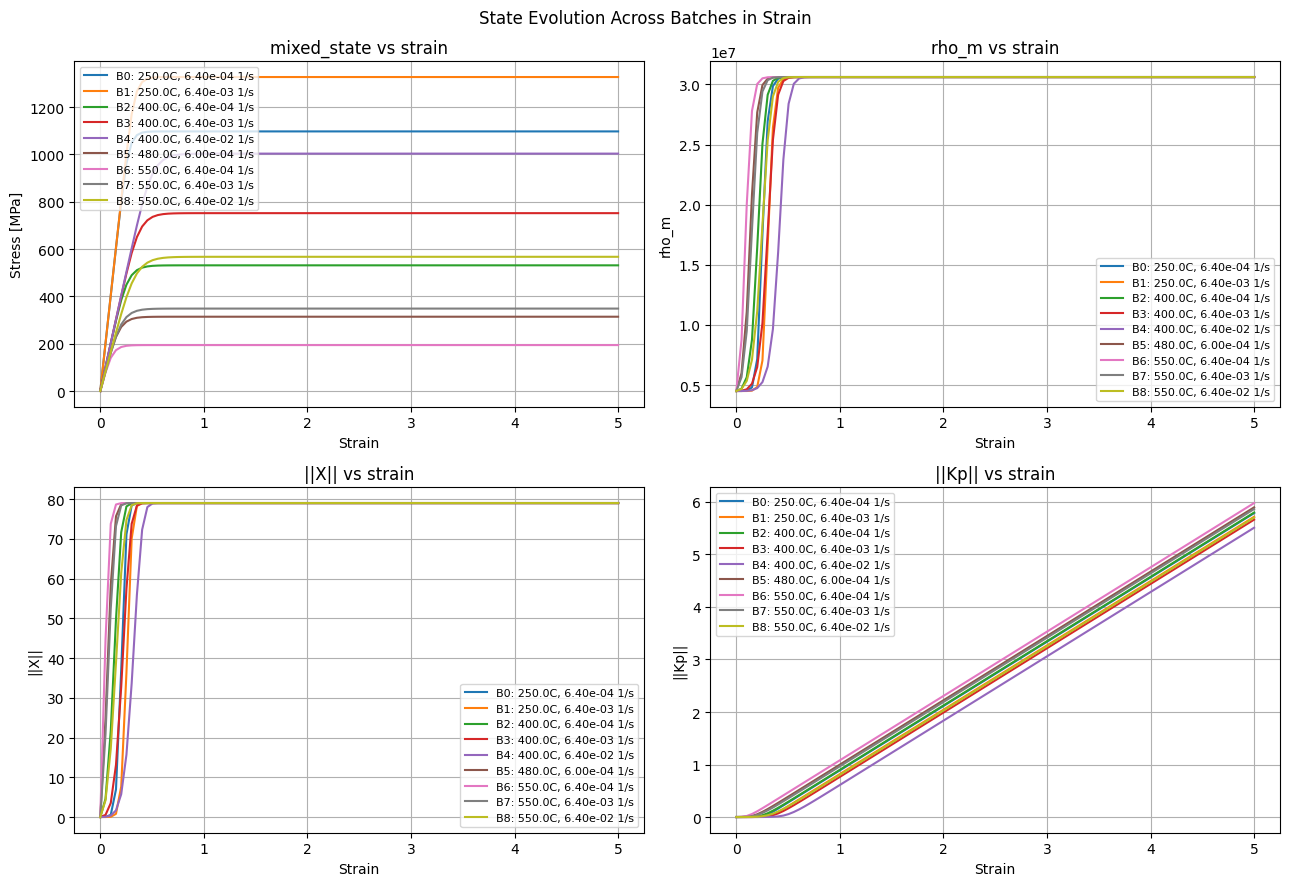

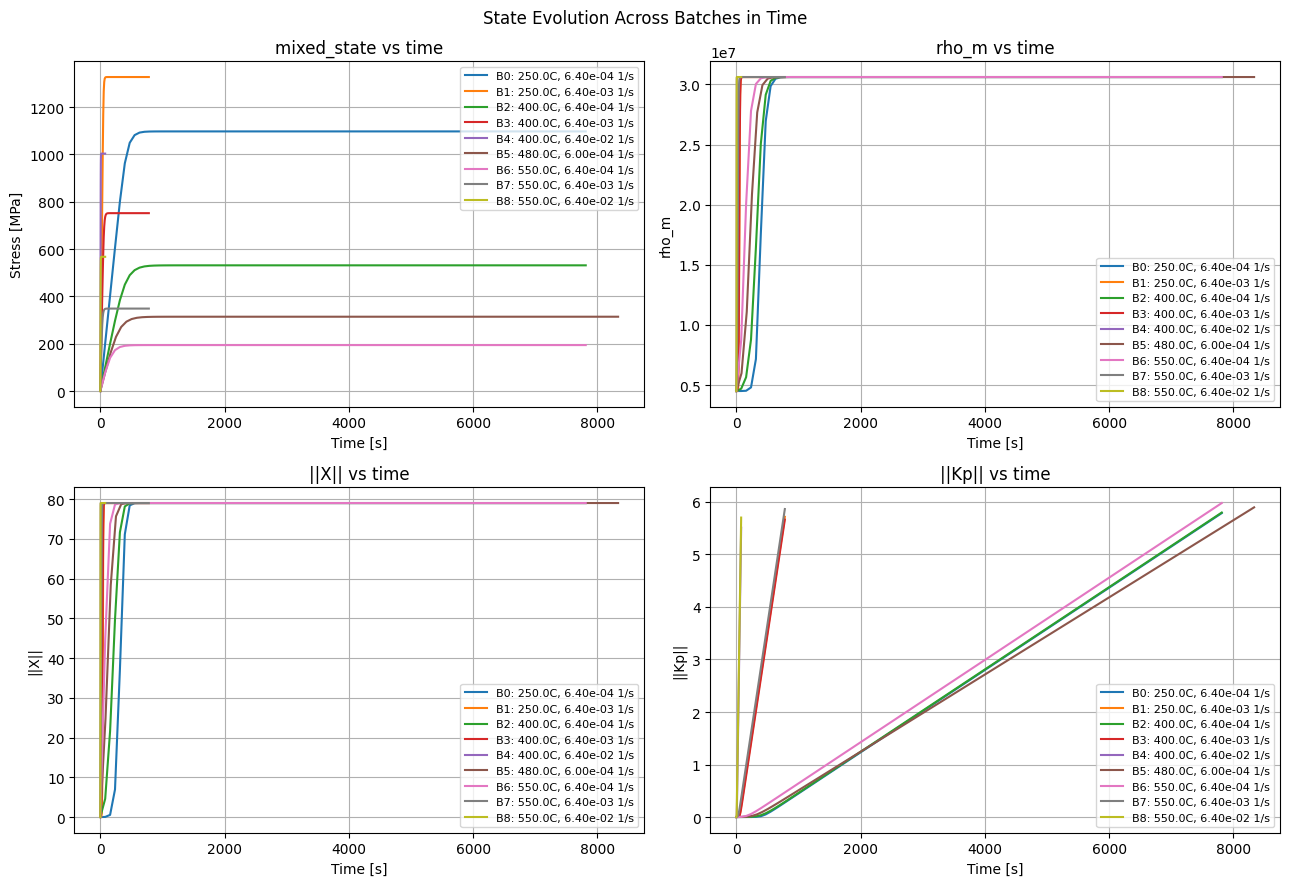

In [91]:
# Debug: inspect internal-variable evolution over time; overlay all batches on two 2x2 figures
with torch.no_grad():
    dbg_solver = nonlinear.RecursiveNonlinearEquationSolver(
        model.discrete_equations,
        step_generator=nonlinear.StepGenerator(model.nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=model.rtol, atol=model.atol),
    )

    dbg_control = torch.zeros_like(loading)
    dbg_control[..., 1:] = 1.0

    dbg_forces = model.discrete_equations.forces_asm.assemble_by_variable(
        {
            "forces/t": time,
            "forces/control": dbg_control,
            "forces/T": temperature,
            "forces/fixed_values": loading,
        }
    ).torch()

    dbg_state0 = model.discrete_equations.state_asm.assemble_by_variable(
        {
            "state/internal/rho_m": torch.full(
                dbg_forces.shape[1:-1] + (1,), model.initial_rho_m, device=dbg_forces.device
            )
        }
    ).torch()

    dbg_results = nonlinear.solve_adjoint(dbg_solver, dbg_state0, len(dbg_forces), dbg_forces)

# Convert VariableName keys to strings for safe filtering/sorting/indexing
state_hist_raw = model.discrete_equations.state_asm.split_by_variable(neml2.Tensor(dbg_results, 2))
state_hist = {str(k): v for k, v in state_hist_raw.items()}

available_names = sorted(state_hist.keys())
print("Available state variables:")
for name in available_names:
    print(" ", name)

def get_hist(name):
    return state_hist[name].torch() if name in state_hist else None

rho_m = get_hist("state/internal/rho_m")
X = get_hist("state/internal/X")
Kp = get_hist("state/internal/Kp")

fig_s, ax_s = plt.subplots(2, 2, figsize=(13, 9))
fig_s.suptitle("State Evolution Across Batches in Strain")

fig_t, ax_t = plt.subplots(2, 2, figsize=(13, 9))
fig_t.suptitle("State Evolution Across Batches in Time")

for i, T in enumerate(temperatures):
    strain_hist = loading[:, i, 0].detach().cpu()
    time_hist = time[:, i, 0].detach().cpu()
    stress11 = stress[:, i, 0].detach().cpu() if stress is not None else None
    rho_m_hist = rho_m[:, i, 0].detach().cpu() if rho_m is not None else None
    x_norm_hist = torch.linalg.norm(X[:, i, :], dim=-1).detach().cpu() if X is not None else None
    kp_norm_hist = torch.linalg.norm(Kp[:, i, :], dim=-1).detach().cpu() if Kp is not None else None

    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"

    print(f"\nBatch {i}: T={temp_c:.1f}C, rate={rate_i:.3e} 1/s")
    if rho_m_hist is not None:
        print(f"rho_m: start={rho_m_hist[0].item():.6e}, end={rho_m_hist[-1].item():.6e}")
    if x_norm_hist is not None:
        print(f"||X||: start={x_norm_hist[0].item():.6e}, end={x_norm_hist[-1].item():.6e}")
    if kp_norm_hist is not None:
        print(f"||Kp||: start={kp_norm_hist[0].item():.6e}, end={kp_norm_hist[-1].item():.6e}")

    if stress11 is not None:
        ax_s[0, 0].plot(strain_hist.numpy(), stress11.numpy(), label=label)
        ax_t[0, 0].plot(time_hist.numpy(), stress11.numpy(), label=label)
    if rho_m_hist is not None:
        ax_s[0, 1].plot(strain_hist.numpy(), rho_m_hist.numpy(), label=label)
        ax_t[0, 1].plot(time_hist.numpy(), rho_m_hist.numpy(), label=label)
    if x_norm_hist is not None:
        ax_s[1, 0].plot(strain_hist.numpy(), x_norm_hist.numpy(), label=label)
        ax_t[1, 0].plot(time_hist.numpy(), x_norm_hist.numpy(), label=label)
    if kp_norm_hist is not None:
        ax_s[1, 1].plot(strain_hist.numpy(), kp_norm_hist.numpy(), label=label)
        ax_t[1, 1].plot(time_hist.numpy(), kp_norm_hist.numpy(), label=label)

ax_s[0, 0].set_title("mixed_state vs strain")
ax_s[0, 0].set_xlabel("Strain")
ax_s[0, 0].set_ylabel("Stress [MPa]")
ax_s[0, 0].grid(True)
ax_s[0, 0].legend(fontsize=8)

ax_s[0, 1].set_title("rho_m vs strain")
ax_s[0, 1].set_xlabel("Strain")
ax_s[0, 1].set_ylabel("rho_m")
ax_s[0, 1].grid(True)
ax_s[0, 1].legend(fontsize=8)

ax_s[1, 0].set_title("||X|| vs strain")
ax_s[1, 0].set_xlabel("Strain")
ax_s[1, 0].set_ylabel("||X||")
ax_s[1, 0].grid(True)
ax_s[1, 0].legend(fontsize=8)

ax_s[1, 1].set_title("||Kp|| vs strain")
ax_s[1, 1].set_xlabel("Strain")
ax_s[1, 1].set_ylabel("||Kp||")
ax_s[1, 1].grid(True)
ax_s[1, 1].legend(fontsize=8)

ax_t[0, 0].set_title("mixed_state vs time")
ax_t[0, 0].set_xlabel("Time [s]")
ax_t[0, 0].set_ylabel("Stress [MPa]")
ax_t[0, 0].grid(True)
ax_t[0, 0].legend(fontsize=8)

ax_t[0, 1].set_title("rho_m vs time")
ax_t[0, 1].set_xlabel("Time [s]")
ax_t[0, 1].set_ylabel("rho_m")
ax_t[0, 1].grid(True)
ax_t[0, 1].legend(fontsize=8)

ax_t[1, 0].set_title("||X|| vs time")
ax_t[1, 0].set_xlabel("Time [s]")
ax_t[1, 0].set_ylabel("||X||")
ax_t[1, 0].grid(True)
ax_t[1, 0].legend(fontsize=8)

ax_t[1, 1].set_title("||Kp|| vs time")
ax_t[1, 1].set_xlabel("Time [s]")
ax_t[1, 1].set_ylabel("||Kp||")
ax_t[1, 1].grid(True)
ax_t[1, 1].legend(fontsize=8)

fig_s.tight_layout()
fig_t.tight_layout()
plt.show()

Loss: 6.13e-02: : 100%|██████████|1000/1000


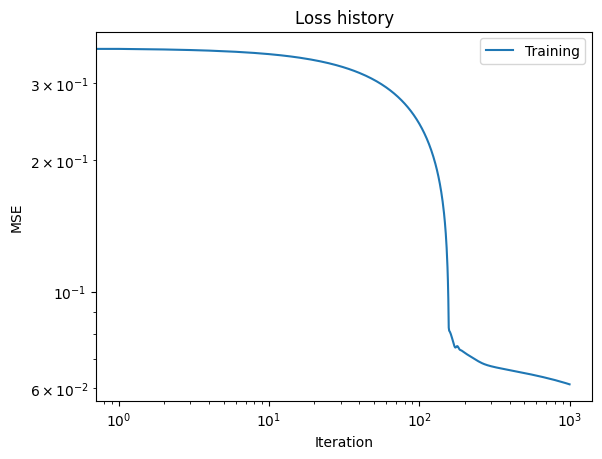

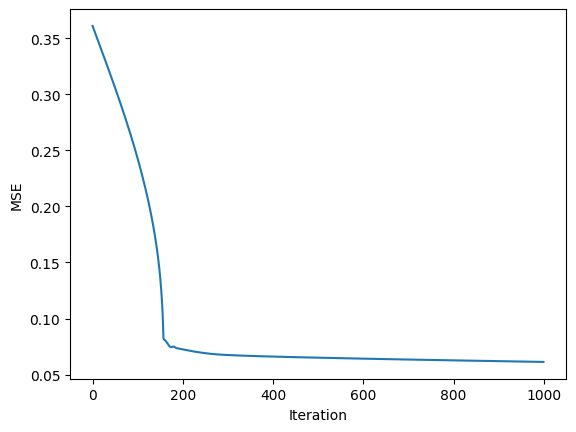

In [92]:
niter = 1000
sensitive_params = ['discrete_equations.parametrizations.Bk_Y.original',
                    'discrete_equations.parametrizations.H_0_Y.original',
                    'discrete_equations.parametrizations.T_0_Y.original']

param_groups = []
for n, p in model.named_parameters():
    if any(fp in n for fp in sensitive_params):
        param_groups.append({'params': [p], 'lr': 1e-5})
    else:
        param_groups.append({'params': [p], 'lr': 1e-4})

optimizer = torch.optim.Adam(param_groups)
loss_fn = torch.nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-7)

peak_stress = exp_stress_data[-1,:,0:1].detach()

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []
for i in titer:
    optimizer.zero_grad()
    try:
        res = model(time, temperature, loading)
        res_norm = res / (peak_stress + 1e-8)
        exp_norm = exp_stress_data[...,0:1] / (peak_stress + 1e-8)
        loss = loss_fn(res_norm, exp_norm)
        if not torch.isfinite(loss) or loss.item() > 1e6:
            titer.set_description(f'Loss: [SKIP bad solve @ iter {i}]')
        loss.backward()
        loss_history.append(loss.detach().clone().cpu())
        titer.set_description("Loss: %3.2e" % loss_history[-1])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.01)
        optimizer.step()
        scheduler.step(loss_history[-1])
    except RuntimeError as e:
        titer.set_description(f'Loss: [SOLVER FAIL @ iter {i}]')
        continue

plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend(loc="best")
plt.title("Loss history")

plt.figure()
plt.plot(range(len(loss_history)), loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()

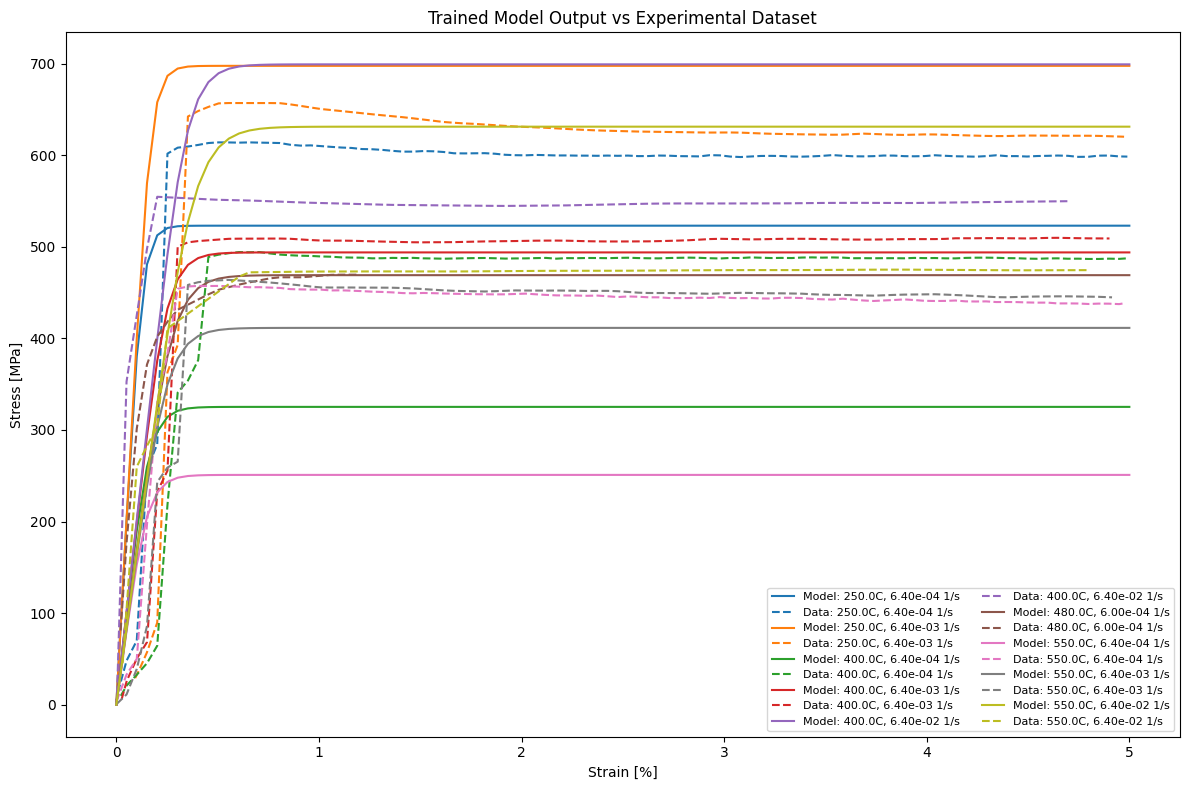

In [94]:
plt.figure(figsize=(12,8))
for i, (T, rate) in enumerate(batch_conditions):
    batch_label = f'{T - 273.15}C, {rate:.2e} 1/s'
    plt.plot(loading[:, i, 0].cpu().numpy(), res[:, i, 0].cpu().detach().numpy(), color=f'C{i}', label=f'Model: {batch_label}')
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--',color=f'C{i}', label=f'Data: {batch_label}')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.xlabel('Strain [%]')
plt.ylabel('Stress [MPa]')
plt.title('Trained Model Output vs Experimental Dataset')
plt.tight_layout()
plt.show()

In [95]:
print("Parameter Optimization Results:")
print("-" * 80)
for n, p in model.named_parameters():
    parts = n.split(".")
    if "parametrizations" in parts:
        param_idx = parts.index("parametrizations")
        simple_name = parts[param_idx - 1] + "." + parts[param_idx + 1]
    scaler = model_reparameterizer.map_dict[simple_name]
    final = scaler(p.data).cpu()
    print(f"\nParameter: {n}")
    print(f"  Initial:  {initial_params[simple_name].cpu()}")
    print(f"  Final:    {final}")
print("-" * 80)

Parameter Optimization Results:
--------------------------------------------------------------------------------

Parameter: discrete_equations.parametrizations.Bk_Y.original
  Initial:  tensor([8.3000e-06, 8.3000e-06, 8.3000e-06, 8.3000e-06, 8.3000e-06, 8.3000e-06,
        8.3000e-06, 8.3000e-06, 8.3000e-06])
  Final:    tensor([8.3000e-06, 1.0000e-08, 2.5691e-07, 8.3000e-06, 8.3000e-06, 2.9554e-05,
        6.3498e-06, 8.3000e-06, 8.3000e-06])

Parameter: discrete_equations.parametrizations.C_Y.original
  Initial:  tensor([41500., 41500., 41500., 41500., 41500., 41500., 41500., 41500., 41500.])
  Final:    tensor([41500.0000, 42677.3848, 46650.1781, 41500.0000, 41500.0000, 44375.2394,
        48432.7285, 41500.0000, 41500.0000])

Parameter: discrete_equations.parametrizations.H_0_Y.original
  Initial:  tensor([1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300, 1.6300])
  Final:    tensor([1.6300, 1.6276, 1.6671, 1.6300, 1.6300, 1.6537, 1.6829, 1.6300, 1.6300])

Parameter:

In [99]:
for i, (T, rate) in enumerate(batch_conditions):
    print(f'B{i}: ({T - 273.15}C, {rate:.2e} 1/s): Exp flow stress: {exp_stress_data[-1, i, 0].item():.2f} MPa, Model flow stress: {res[-1, i, 0].item():.2f} MPa')

B0: (250.0C, 6.40e-04 1/s): Exp flow stress: 598.44 MPa, Model flow stress: 523.01 MPa
B1: (250.0C, 6.40e-03 1/s): Exp flow stress: 620.14 MPa, Model flow stress: 697.54 MPa
B2: (400.0C, 6.40e-04 1/s): Exp flow stress: 487.47 MPa, Model flow stress: 325.17 MPa
B3: (400.0C, 6.40e-03 1/s): Exp flow stress: 509.05 MPa, Model flow stress: 493.83 MPa
B4: (400.0C, 6.40e-02 1/s): Exp flow stress: 549.74 MPa, Model flow stress: 699.16 MPa
B5: (480.0C, 6.00e-04 1/s): Exp flow stress: 469.51 MPa, Model flow stress: 468.98 MPa
B6: (550.0C, 6.40e-04 1/s): Exp flow stress: 438.13 MPa, Model flow stress: 250.91 MPa
B7: (550.0C, 6.40e-03 1/s): Exp flow stress: 444.78 MPa, Model flow stress: 411.43 MPa
B8: (550.0C, 6.40e-02 1/s): Exp flow stress: 474.50 MPa, Model flow stress: 631.11 MPa
